# Setup

In [2]:
import gc
import os
import sys
import logging
import warnings
from pathlib import Path
import matplotlib as mpl
import pickle
import session_info

SRCDIR = Path('../../..')
HOMEDIR = SRCDIR / '..'
PLOTDIR = HOMEDIR / "plots" / "kennedi_xenium"
DATADIR = HOMEDIR / "data" / "processed" / "spatial" / "Xenium" / "kennedi_flu"
if not str(SRCDIR) in sys.path:
    sys.path.insert(0, str(SRCDIR))

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", DeprecationWarning)

from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

import squidpy as sq
import cellcharter as cc
# import spatialdata as sd
# import spatialdata_plot as sdp

CORES = 20
%matplotlib inline
# R_preload()
mpl.rcdefaults()
plt.rcParams["figure.figsize"] = (8, 8)
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/ome_zarr/writer.py:967: DeprecationWarning: Call to deprecated class Scaler. (Downsampling via the `Scaler` class has been deprecated. Please use the `scale_factors` argument instead.) -- Deprecated since version 0.14.0.
/mnt/DATA/home/ethung/projects/spatial_seq/.pi

In [3]:
niche_key = "cellcharter_k12"
celltype_key = "LabelTransfer_OT"
sample1 = "Ctrl_D14_2"

# Squidpy metrics

In [ ]:
# load
adata = sc.read_h5ad(DATADIR / "integrated.h5ad")
adata

In [ ]:
cc.tl.boundaries(adata, niche_key)
cc.pl.boundaries(adata, "Ctrl_D14_1", "Sample", niche_key)

### Composition

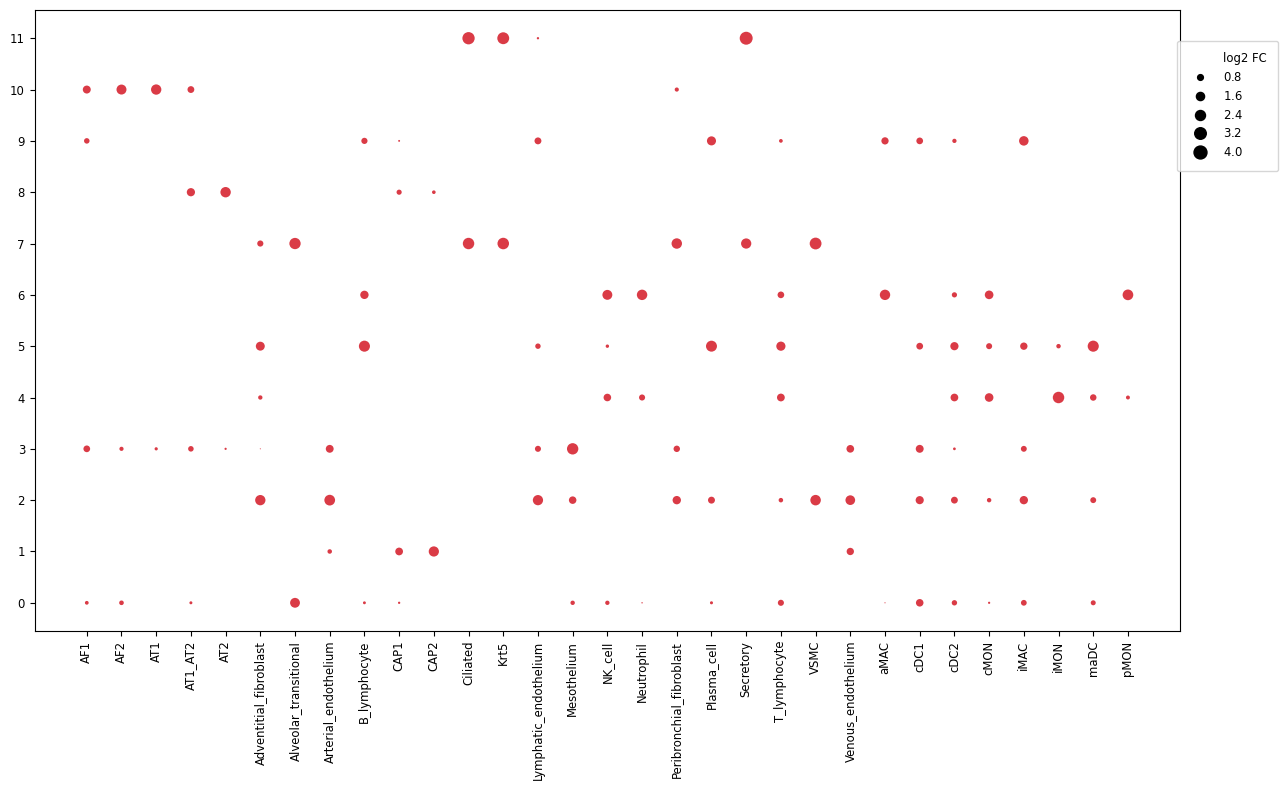

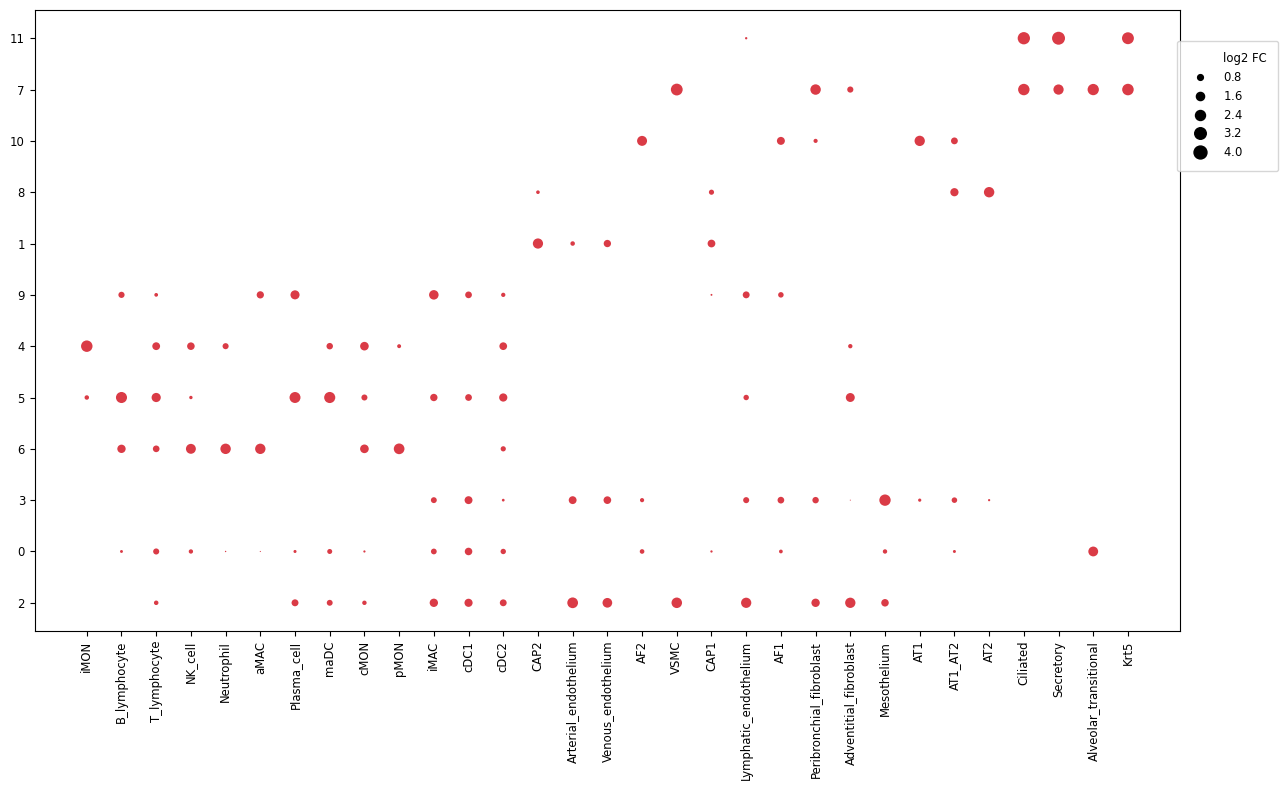

In [14]:
cc.gr.enrichment(adata, niche_key, celltype_key)
cc.pl.enrichment(adata, niche_key, celltype_key,
                 group_cluster=False,
                 figsize=(12,8),
                 save=PLOTDIR / "niches" / f"CompositionEnrichment-{niche_key}.jpg")
cc.pl.enrichment(adata, niche_key, celltype_key,
                 group_cluster=True, label_cluster=True,
                 figsize=(12,8),
                 save=PLOTDIR / "niches" / f"CompositionEnrichment-{niche_key}-Clustered.jpg")

In [ ]:
# neighborhood composition
f = plt.figure(figsize=(20, 12), layout="constrained")
sf = f.subfigures(1,2,width_ratios=[1.3,2])
plot_cluster_stackedbarplot(adata, niche_key, celltype_key, pct=True, ax=sf[0].subplots(1, 1))
plot_cluster_stackedbarplot(adata, celltype_key, niche_key, pct=True, ax=sf[1].subplots(1, 1))
f.suptitle("Composition Barplots")
f.savefig(PLOTDIR / "niches" / f"CompositionBarplot-{niche_key}_celltype.jpg")

crosstab = pd.crosstab(adata.obs[celltype_key], adata.obs[niche_key]).astype(int)
f, axs = plt.subplots(1, 2, figsize=(25, 15), layout="constrained")
sns.heatmap(
    crosstab.div(crosstab.sum(axis=1), axis=0),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[0],
)
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(
    crosstab.div(crosstab.sum(axis=0), axis=1),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[1],
)
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood\n(count annotated)", size=18)
f.savefig(PLOTDIR / "niches" / f"CompositionHeatmap-{niche_key}_celltype.jpg")

### Proximity Enrichment

In [ ]:
# proximity enrichment
RUN = False
# clear_uns(adata, "nhood")

for key in [niche_key, celltype_key]:
    if RUN is True:
        cc.gr.nhood_enrichment(adata, cluster_key=key, n_jobs=CORES, pvalues=True)
    cc.pl.nhood_enrichment(
        adata,
        cluster_key=key,
        annotate=True,
        vmin=-1,
        vmax=1,
        figsize=(5,5) if key==niche_key else (15,15),
        cmap="RdBu_r",
        title=f"Proximity enrichment ({key})",
        save=PLOTDIR / "niches" / f"ProximityEnrichment-{key}.jpg"
    )

In [ ]:
# differential proximity enrichment
RUN = True

for key in [niche_key, celltype_key]:
    if RUN is True:
        cc.gr.diff_nhood_enrichment(
            adata, cluster_key=key, condition_key="Groups"
            n_jobs=CORES, pvalues=True, library_key="Sample")
    cc.pl.nhood_enrichment(
        adata,
        cluster_key=key,
        annotate=True,
        vmin=-1,
        vmax=1,
        figsize=(5,5) if key==niche_key else (15,15),
        cmap="RdBu_r",
        title=f"Differential Proximity enrichment ({key})",
        save=PLOTDIR / f"{niche_key}-DiffProximityEnrichment.jpg"
    )

### Co-Occurrence

In [ ]:
adata_samp1 = adata[adata.obs["Sample"] == sample1]
f,ax = plt.subplots(1,1, figsize=(25,10))
sc.pl.embedding(adata_samp1, "SPATIAL", color=niche_key, ax=ax, show=False, size=5)
for r in [100,250,500,1000,2000]:
    circle = plt.Circle((20000, 29000), r, color='black', fill=False, linewidth=1.5)
    ax.text(20000, 29000+r, r, fontsize=10, ha='center', va='bottom')
    ax.add_patch(circle)

In [ ]:
set_interval = np.arange(0, 500, 10)

for key in [niche_key, celltype_key]:
    sq.gr.co_occurrence(
        adata_samp1,
        cluster_key=key,
        spatial_key="SPATIAL",
        interval=set_interval,
        n_jobs=CORES,
    )

    sq.pl.co_occurrence(
        adata, cluster_key=key
    )

In [ ]:
# run = False
# if run is True:
#     warnings.filterwarnings("ignore")
#     split_adatas = {}
#     for sample in tqdm(adata.obs["sample"].unique()):
#         tmp = adata[adata.obs["sample"] == sample].copy()
#         sq.gr.co_occurrence(
#             tmp,
#             spatial_key="SPATIAL",
#             n_jobs=CORES,
#             interval=set_interval,
#             cluster_key="celltype",
#             show_progress_bar=False,
#         )
#         split_adatas[sample] = tmp

# SAMPLES = pd.Series(split_adatas.keys())

# for tp in adata.obs["timepoint"].cat.categories:
#     adata.uns['celltype_co_occurrence'] = {}
#     adata.uns['celltype_co_occurrence']['occ'] = np.add.reduce(
#         [split_adatas[sample].uns['celltype_co_occurrence']['occ'] for sample in SAMPLES[SAMPLES.str.contains(tp)]]
#     )
#     adata.uns['celltype_co_occurrence']['interval'] = set_interval

#     sq.pl.co_occurrence(
#         adata, cluster_key="celltype", clusters="Neu Phox2b+"
#     )

### Ripley's statistic (distribution)

In [ ]:
# sq.gr.ripley(adata, cluster_key=, mode=mode)

# Hotspot

In [ ]:
with open(DATADIR / "tools" / "hotspotSC" /  "hotspot.pkl", 'rb') as f:
    hs = pickle.load(f)

In [ ]:
THRESHOLD = 10

modules = hs.create_modules(
    min_gene_threshold=THRESHOLD, core_only=False, fdr_threshold=0.05
)

hs.plot_local_correlations()
print(modules.value_counts())

module_scores = hs.calculate_module_scores()

module_cols = []
for c in module_scores.columns:
    key = f"HotspotModule-{c}"
    adata.obs[key] = module_scores[c]
    module_cols.append(key)
obs_to_obsm(adata, "HotspotModule", 1)

results = hs.results.join(hs.modules)

adata.uns["hotspot"] = {
    "gene_df" : results,
    "FDR" : 0.01,
    "MinModuleSize" : THRESHOLD
}

In [ ]:
module = 2
genes = results.loc[results.Module == module].sort_values('Z', ascending=False).head(6).index

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'grays', ['#DDDDDD', '#000000'])

sc.pl.spatial(
    adata, 
    color=genes, 
    cmap=cmap, 
    frameon=False,
    vmin='p0',
    vmax='p95',
    spot_size=30,
)

# Save/Load

In [20]:
# save
adata.write(DATADIR / "integrated.h5ad")
adata

AnnData object with n_obs × n_vars = 4654531 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Slide', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Genotype', 'Timepoint', 'cellcharter_k3', 'cellcharter_k6', 'cellcharter_k12', 'LabelTransfer_OT', 'Groups'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'LabelTransfer_OT_nhood_enrichment', 'PCA', 'UMAP', 'cellcharter_k12_nhood_enrichment', 'cellcharter_k6_LabelTransfer_OT_enrichment', 'cellcharter_k6_nhood_enrichment', 'global_leiden_Info', 'hotspot', 'log1p', 'methods', 'neighbors', 'spatial_neighbo

In [4]:
# load
adata = sc.read_h5ad(DATADIR / "integrated.h5ad")
adata

AnnData object with n_obs × n_vars = 4654531 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Slide', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Genotype', 'Timepoint', 'cellcharter_k3', 'cellcharter_k6', 'cellcharter_k12', 'LabelTransfer_OT', 'Groups'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'LabelTransfer_OT_nhood_enrichment', 'PCA', 'UMAP', 'cellcharter_k12_nhood_enrichment', 'cellcharter_k6_LabelTransfer_OT_enrichment', 'cellcharter_k6_nhood_enrichment', 'global_leiden_Info', 'hotspot', 'log1p', 'methods', 'neighbors', 'spatial_neighbo